# Phase 5 - Dashboard and Full Evaluation

Student: Mike Sayanka Lekaram

ID: GC3183502

Module: Thesis / Dissertation

Institution: Griffith College Dublin

## Information about the notebook

Part 1 - Dashboard
  Builds a Plotly Dash web dashboard that reads the predictions
  saved in Phase 4 and displays them visually. The dashboard
  runs inside Colab using a tunnel so it can be viewed in a browser.

Part 2 - Full evaluation
  Produces the final results table and charts for Chapter 5.
  Compares my model performance against published benchmarks
  from the literature review.

NOTE: connect T4 GPU first.
Runtime -> Change runtime type -> T4 GPU -> Save

## 1.  Mount Drive and install libraries

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

base       = '/content/drive/MyDrive/FakeNewsThesis'
data_dir   = base + '/data'
model_dir  = base + '/model'
charts_dir = base + '/charts'
db_path    = base + '/predictions.db'

os.makedirs(charts_dir, exist_ok=True)

print('Drive mounted')
print('predictions db:', db_path)

# install dash and a tunnel library so we can view it in the browser
print('installing libraries...')
os.system('pip install dash plotly pyngrok transformers==4.41.0 -q')
print('done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
predictions db: /content/drive/MyDrive/FakeNewsThesis/predictions.db
installing libraries...
done


## 2. Import libraries and check what is in the database

Load the predictions saved in Phase 4 and check everything
looks correct before building the dashboard.

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# load predictions from Phase 4
conn = sqlite3.connect(db_path)
preds_df = pd.read_sql('SELECT * FROM predictions', conn)
conn.close()

print()
print('predictions loaded:', len(preds_df), 'rows')
print()
print('sample:')
print(preds_df[['article_id', 'label_text', 'confidence', 'processed']].head(5).to_string(index=False))
print()
print('breakdown:')
print(preds_df['label_text'].value_counts().to_string())

device: cuda

predictions loaded: 100 rows

sample:
 article_id label_text  confidence           processed
          1       real      0.9999 2026-08-25 12:53:18
          2       real      0.9875 2026-08-25 12:53:18
          3       real      0.9999 2026-08-25 12:53:18
          4       real      0.9999 2026-08-25 12:53:18
          5       real      0.9999 2026-08-25 12:53:18

breakdown:
label_text
real    56
fake    44


## 3.  Build the Plotly Dash dashboard

This creates a simple web dashboard with four panels:
  1. summary stats at the top
  2. real vs fake pie chart
  3. confidence score histogram
  4. recent predictions table

The dashboard runs on a local port and opens in your browser
via an ngrok tunnel. You will get a URL to click.

In [3]:
import sqlite3
import pandas as pd
from dash import Dash, html, dcc, dash_table
import plotly.express as px
from pyngrok import ngrok
import threading, time
ngrok.kill()

ngrok.set_auth_token('3HkPdsb4L3883vcRJIOjztwOAdz_BheBh7u2SXToTR86hn8Y')

# load predictions
conn     = sqlite3.connect(db_path)
preds_df = pd.read_sql('SELECT * FROM predictions', conn)
conn.close()

total      = len(preds_df)
real_count = len(preds_df[preds_df['label_text'] == 'real'])
fake_count = len(preds_df[preds_df['label_text'] == 'fake'])
avg_conf   = round(preds_df['confidence'].mean(), 4)

# pie chart
label_counts = preds_df['label_text'].value_counts().reset_index()
label_counts.columns = ['label', 'count']

pie_fig = px.pie(
    label_counts, values='count', names='label',
    color='label',
    color_discrete_map={'real': 'steelblue', 'fake': 'darkorange'},
    title='real vs fake classification'
)
pie_fig.update_layout(
    autosize=True,
    margin=dict(l=10, r=10, t=40, b=10),
    legend=dict(orientation='h', y=-0.1),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# confidence histogram - overlapping bars
hist_fig = px.histogram(
    preds_df, x='confidence', color='label_text',
    color_discrete_map={'real': 'steelblue', 'fake': 'darkorange'},
    nbins=20, barmode='overlay', opacity=0.7,
    title='confidence score distribution',
    labels={'confidence': 'confidence score', 'count': 'number of articles'}
)
hist_fig.update_layout(
    autosize=True,
    margin=dict(l=10, r=10, t=40, b=10),
    legend=dict(orientation='h', y=-0.15),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# recent predictions table - last 8 rows
recent = preds_df[['article_id', 'label_text', 'confidence', 'processed']].tail(8)

# build the app
app = Dash(__name__)

app.layout = html.Div([

    # header
    html.Div([
        html.H2(
            'Fake News Detection Dashboard',
            style={'margin': '0', 'fontSize': '17px', 'color': '#2c3e50'}
        ),
        html.P(
            'GC3183502 | Mike Sayanka Lekaram | Griffith College Dublin',
            style={'margin': '2px 0 0 0', 'fontSize': '11px', 'color': '#7f8c8d'}
        ),
    ], style={
        'background': '#ffffff',
        'padding': '10px 20px',
        'borderBottom': '2px solid #2980b9'
    }),

    # stats row
    html.Div([
        html.Div([
            html.Div(str(total),
                     style={'fontSize': '26px', 'fontWeight': 'bold', 'color': '#2980b9'}),
            html.Div('total processed',
                     style={'fontSize': '11px', 'color': '#7f8c8d'})
        ], style={'flex': '1', 'textAlign': 'center', 'padding': '10px',
                  'background': '#fff', 'borderRadius': '6px', 'margin': '4px',
                  'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}),

        html.Div([
            html.Div(str(real_count),
                     style={'fontSize': '26px', 'fontWeight': 'bold', 'color': 'steelblue'}),
            html.Div('real articles',
                     style={'fontSize': '11px', 'color': '#7f8c8d'})
        ], style={'flex': '1', 'textAlign': 'center', 'padding': '10px',
                  'background': '#fff', 'borderRadius': '6px', 'margin': '4px',
                  'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}),

        html.Div([
            html.Div(str(fake_count),
                     style={'fontSize': '26px', 'fontWeight': 'bold', 'color': 'darkorange'}),
            html.Div('fake articles',
                     style={'fontSize': '11px', 'color': '#7f8c8d'})
        ], style={'flex': '1', 'textAlign': 'center', 'padding': '10px',
                  'background': '#fff', 'borderRadius': '6px', 'margin': '4px',
                  'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}),

        html.Div([
            html.Div(str(avg_conf),
                     style={'fontSize': '26px', 'fontWeight': 'bold', 'color': '#27ae60'}),
            html.Div('avg confidence',
                     style={'fontSize': '11px', 'color': '#7f8c8d'})
        ], style={'flex': '1', 'textAlign': 'center', 'padding': '10px',
                  'background': '#fff', 'borderRadius': '6px', 'margin': '4px',
                  'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}),

    ], style={'display': 'flex', 'padding': '6px 10px', 'background': '#f0f4f8'}),

    # charts row
    html.Div([
        html.Div([
            dcc.Graph(
                figure=pie_fig,
                responsive=True,
                style={'height': '260px', 'width': '100%'},
                config={'displayModeBar': False, 'responsive': True}
            )
        ], style={'flex': '1', 'background': '#fff', 'borderRadius': '6px',
                  'margin': '4px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)',
                  'minWidth': '0'}),

        html.Div([
            dcc.Graph(
                figure=hist_fig,
                responsive=True,
                style={'height': '260px', 'width': '100%'},
                config={'displayModeBar': False, 'responsive': True}
            )
        ], style={'flex': '1', 'background': '#fff', 'borderRadius': '6px',
                  'margin': '4px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)',
                  'minWidth': '0'}),

    ], style={'display': 'flex', 'padding': '4px 10px', 'background': '#f0f4f8'}),

    # predictions table
    html.Div([
        html.Div('recent predictions',
                 style={'fontSize': '13px', 'fontWeight': 'bold',
                        'color': '#2c3e50', 'marginBottom': '6px'}),
        dash_table.DataTable(
            data=recent.to_dict('records'),
            columns=[{'name': c, 'id': c} for c in recent.columns],
            style_table={'overflowX': 'auto', 'width': '100%'},
            style_cell={
                'fontFamily': 'Arial', 'fontSize': '11px',
                'textAlign': 'left', 'padding': '5px 8px',
                'maxWidth': '180px', 'overflow': 'hidden',
                'textOverflow': 'ellipsis', 'whiteSpace': 'nowrap'
            },
            style_header={
                'backgroundColor': '#2980b9', 'color': 'white',
                'fontWeight': 'bold', 'fontSize': '11px'
            },
            style_data_conditional=[
                {'if': {'filter_query': '{label_text} = fake'},
                 'backgroundColor': '#fef9e7', 'color': '#d35400'},
                {'if': {'filter_query': '{label_text} = real'},
                 'backgroundColor': '#eaf4fb', 'color': '#1a5276'},
            ]
        )
    ], style={
        'margin': '4px 14px 10px 14px',
        'background': '#fff', 'borderRadius': '6px',
        'padding': '10px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'
    }),

], style={
    'fontFamily': 'Arial',
    'backgroundColor': '#f0f4f8',
    'width': '100%',
    'maxWidth': '100vw',
    'overflow': 'hidden',
    'boxSizing': 'border-box'
})


def run_app():
    app.run(port=8050, debug=False, use_reloader=False)

thread = threading.Thread(target=run_app, daemon=True)
thread.start()
time.sleep(3)

public_url = ngrok.connect(8050)
print()
print('dashboard running:', public_url)
print()
print('when the page opens:')
print('  1. wait 2 seconds for charts to fully load')
print('  2. press Ctrl + - once to zoom out')
print('  3. press F5 to reload - charts render at correct size')
print('  4. take your screenshot')




<IPython.core.display.Javascript object>


dashboard running: NgrokTunnel: "https://spew-smilingly-component.ngrok-free.dev" -> "http://localhost:8050"

when the page opens:
  1. wait 2 seconds for charts to fully load
  2. press Ctrl + - once to zoom out
  3. press F5 to reload - charts render at correct size
  4. take your screenshot


## 4.  Save a screenshot of the dashboard as a chart

This saves a static version of the dashboard charts to Drive
for inclusion in the thesis. Run this after you have seen
the dashboard working in your browser.

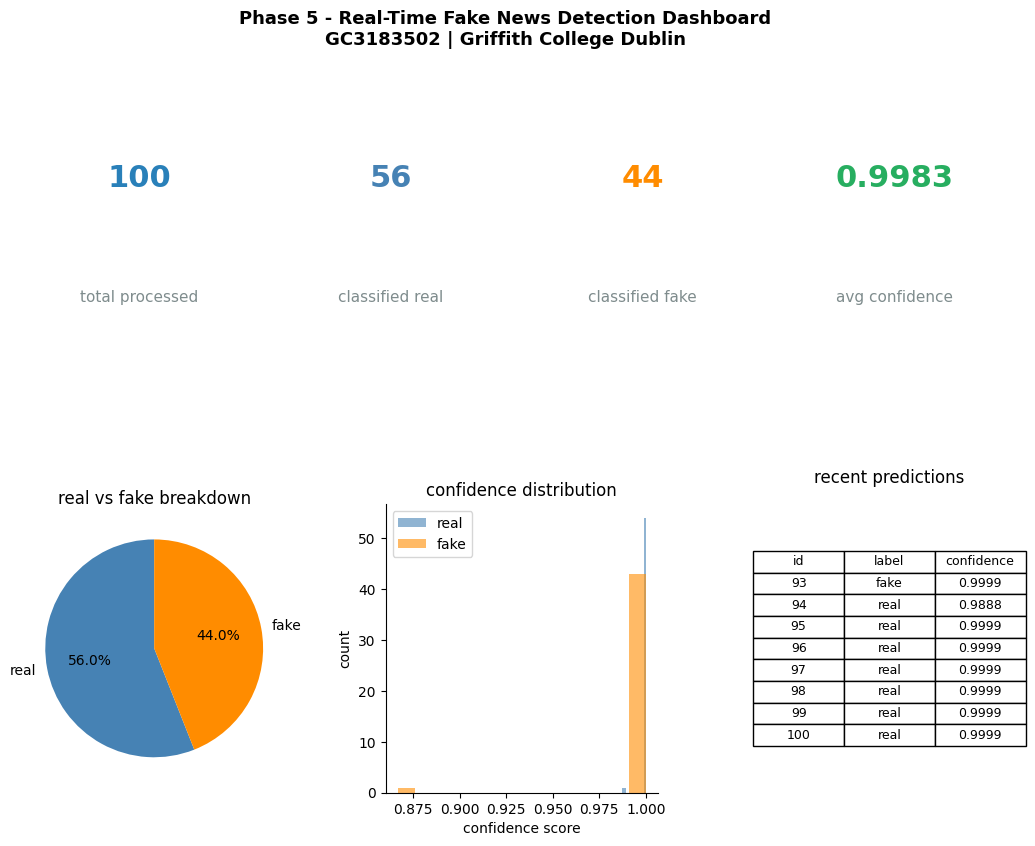

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase5_dashboard.png


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

conn     = sqlite3.connect(db_path)
preds_df = pd.read_sql('SELECT * FROM predictions', conn)
conn.close()

total      = len(preds_df)
real_count = len(preds_df[preds_df['label_text'] == 'real'])
fake_count = len(preds_df[preds_df['label_text'] == 'fake'])
avg_conf   = round(preds_df['confidence'].mean(), 4)

fig = plt.figure(figsize=(13, 9))
fig.suptitle(
    'Phase 5 - Real-Time Fake News Detection Dashboard\nGC3183502 | Griffith College Dublin',
    fontsize=13, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# summary stats across the top
ax_stats = fig.add_subplot(gs[0, :])
ax_stats.axis('off')
stats = [
    ('total processed', str(total),      '#2980b9'),
    ('classified real', str(real_count), 'steelblue'),
    ('classified fake', str(fake_count), 'darkorange'),
    ('avg confidence',  str(avg_conf),   '#27ae60'),
]
for i, (label, value, colour) in enumerate(stats):
    x = 0.12 + i * 0.25
    ax_stats.text(x, 0.7, value, transform=ax_stats.transAxes,
                  fontsize=22, fontweight='bold', color=colour, ha='center')
    ax_stats.text(x, 0.3, label, transform=ax_stats.transAxes,
                  fontsize=11, color='#7f8c8d', ha='center')

# pie chart
ax_pie = fig.add_subplot(gs[1, 0])
counts = [real_count, fake_count]
labels = ['real', 'fake']
colours = ['steelblue', 'darkorange']
ax_pie.pie(counts, labels=labels, colors=colours,
           autopct='%1.1f%%', startangle=90)
ax_pie.set_title('real vs fake breakdown')

# confidence histogram
ax_hist = fig.add_subplot(gs[1, 1])
real_conf = preds_df[preds_df['label_text'] == 'real']['confidence']
fake_conf = preds_df[preds_df['label_text'] == 'fake']['confidence']
ax_hist.hist(real_conf, bins=15, alpha=0.6, color='steelblue',  label='real')
ax_hist.hist(fake_conf, bins=15, alpha=0.6, color='darkorange', label='fake')
ax_hist.set_xlabel('confidence score')
ax_hist.set_ylabel('count')
ax_hist.set_title('confidence distribution')
ax_hist.legend()
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)

# recent predictions as a text table in the third panel
ax_table = fig.add_subplot(gs[1, 2])
ax_table.axis('off')
recent = preds_df[['article_id', 'label_text', 'confidence']].tail(8)
table_data = recent.values.tolist()
col_labels = ['id', 'label', 'confidence']
tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.3)
ax_table.set_title('recent predictions', pad=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
p1 = charts_dir + '/phase5_dashboard.png'
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p1)

## 5.  Full model evaluation on the complete test set

This runs the final evaluation using the complete held-out
test set from Phase 2. This is the official accuracy figure
that goes into Chapter 5 of the thesis.

I also compare against the published benchmarks from the
literature review to show how my model performs relative
to prior work.

In [7]:
import torch
import torch.nn as nn
import pandas as pd
import time
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix,
    roc_auc_score
)

BERT_MODEL = 'distilbert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 16

# rebuild model class
class BertBiLSTMModel(nn.Module):
    def __init__(self, bert_name, hidden=128, num_classes=2, dropout=0.3):
        super(BertBiLSTMModel, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        bert_size = self.bert.config.hidden_size
        self.bilstm = nn.LSTM(
            input_size=bert_size, hidden_size=hidden,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.2
        )
        self.attention = nn.Linear(hidden * 2, 1)
        self.drop  = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden * 2, 64)
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, input_ids, attention_mask=None):
        bert_out = self.bert(
            input_ids=input_ids, attention_mask=attention_mask)
        seq = bert_out.last_hidden_state
        lstm_out, _ = self.bilstm(seq)
        weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        out = self.drop(context)
        out = self.relu(self.dense(out))
        out = self.drop(out)
        return self.fc(out)


# load tokenizer and model
print('loading tokenizer and model...')
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

model = BertBiLSTMModel(BERT_MODEL)
model.load_state_dict(
    torch.load(model_dir + '/model3_bert_bilstm_hybrid.pt', map_location=device)
)
model = model.to(device)
model.eval()
print('model loaded')

# dataset class
class TestDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(
            str(self.texts[i]),
            max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[i], dtype=torch.long)
        }

# load full test set
test_df = pd.read_csv(data_dir + '/test.csv')
test_df = test_df.dropna(subset=['text', 'label']).reset_index(drop=True)
print('test set:', len(test_df), 'articles')

test_loader = DataLoader(
    TestDataset(test_df['text'], test_df['label']),
    batch_size=BATCH_SIZE
)

# run inference on the full test set
print('running evaluation...')
all_preds, all_labels, all_probs = [], [], []
start = time.time()

with torch.no_grad():
    for batch in test_loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

elapsed = time.time() - start

# calculate all metrics
accuracy  = accuracy_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
auc_roc   = roc_auc_score(all_labels, all_probs)
avg_latency_ms = (elapsed / len(test_df)) * 1000

print()
print('=' * 55)
print('final evaluation results - BERT+BiLSTM hybrid')
print('=' * 55)
print('  test articles :', len(test_df))
print('  accuracy      :', round(accuracy * 100, 2), '%')
print('  f1 score      :', round(f1, 4))
print('  precision     :', round(precision, 4))
print('  recall        :', round(recall, 4))
print('  auc-roc       :', round(auc_roc, 4))
print('  total time    :', round(elapsed, 1), 'sec')
print('  avg per article:', round(avg_latency_ms, 2), 'ms')
print('=' * 55)
print()
print('detailed report:')
print(classification_report(all_labels, all_preds,
                             target_names=['fake', 'real']))

loading tokenizer and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model loaded
test set: 7152 articles
running evaluation...

final evaluation results - BERT+BiLSTM hybrid
  test articles : 7152
  accuracy      : 99.04 %
  f1 score      : 0.9904
  precision     : 0.9904
  recall        : 0.9904
  auc-roc       : 0.9995
  total time    : 43.7 sec
  avg per article: 6.11 ms

detailed report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3503
        real       0.99      0.99      0.99      3649

    accuracy                           0.99      7152
   macro avg       0.99      0.99      0.99      7152
weighted avg       0.99      0.99      0.99      7152



##  6.  Comparison against published benchmarks

This compares my results against the papers reviewed
in Chapter 2 (Literature Review). This table goes
directly into Chapter 5 of the thesis.

comparison against published benchmarks
rank  model                                    accuracy source
-----------------------------------------------------------------
1     My model: BERT+BiLSTM (GC3183502)          99.04% this thesis <-- my model
2     FakeBERT (Kaliyar et al. 2021)             98.90% Springer
3     BERT-TCN (Sultan et al. 2024)              98.63% Springer
4     BERT+LightGBM (Essa et al. 2023)           96.94% Springer
5     GBERT (Dhiman et al. 2024)                 95.30% ScienceDirect
6     Progressive BERT (2025)                    95.30% PMC


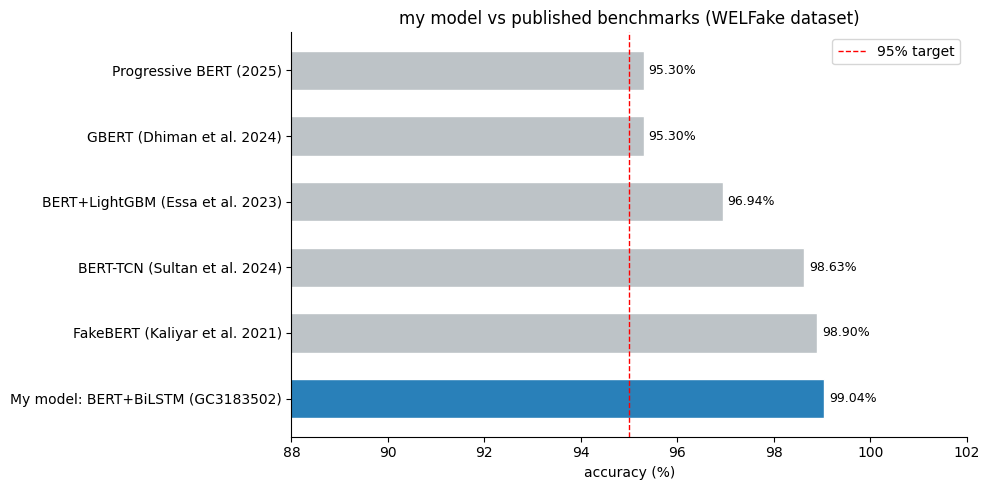

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase5_benchmark_comparison.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# published benchmark results from the literature review
# sources are cited in Chapter 2
benchmarks = [
    {'model': 'FakeBERT (Kaliyar et al. 2021)',   'accuracy': 98.90, 'source': 'Springer'},
    {'model': 'BERT-TCN (Sultan et al. 2024)',     'accuracy': 98.63, 'source': 'Springer'},
    {'model': 'BERT+LightGBM (Essa et al. 2023)', 'accuracy': 96.94, 'source': 'Springer'},
    {'model': 'GBERT (Dhiman et al. 2024)',        'accuracy': 95.30, 'source': 'ScienceDirect'},
    {'model': 'Progressive BERT (2025)',           'accuracy': 95.30, 'source': 'PMC'},
    {'model': 'My model: BERT+BiLSTM (GC3183502)', 'accuracy': round(accuracy * 100, 2), 'source': 'this thesis'},
]

bench_df = pd.DataFrame(benchmarks)
bench_df  = bench_df.sort_values('accuracy', ascending=False).reset_index(drop=True)

# print the comparison table
print('comparison against published benchmarks')
print('=' * 65)
print('{:<5} {:<38} {:>10} {}'.format('rank', 'model', 'accuracy', 'source'))
print('-' * 65)
for i, row in bench_df.iterrows():
    flag = ' <-- my model' if 'GC3183502' in row['model'] else ''
    print('{:<5} {:<38} {:>9.2f}% {}{}'.format(
        i + 1, row['model'], row['accuracy'], row['source'], flag))
print('=' * 65)

# bar chart
colours = ['#2980b9' if 'GC3183502' in m else '#bdc3c7'
           for m in bench_df['model']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    bench_df['model'], bench_df['accuracy'],
    color=colours, edgecolor='white', height=0.6
)

for bar, val in zip(bars, bench_df['accuracy']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        '{:.2f}%'.format(val),
        va='center', fontsize=9
    )

ax.set_xlabel('accuracy (%)')
ax.set_xlim(88, 102)
ax.set_title('my model vs published benchmarks (WELFake dataset)')
ax.axvline(x=95, color='red', linestyle='--', linewidth=1, label='95% target')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
p2 = charts_dir + '/phase5_benchmark_comparison.png'
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p2)

## 7.  Final confusion matrix for the thesis

A clean confusion matrix using the full test set results.
This goes into Chapter 5 as the official evaluation figure.

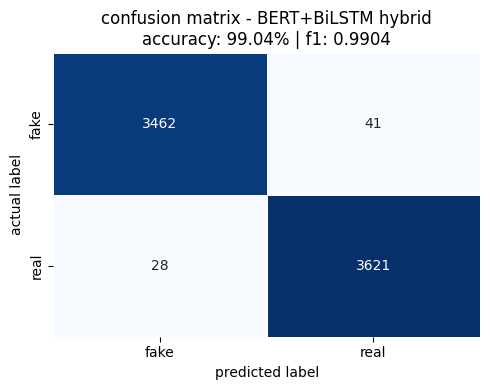

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase5_final_confusion_matrix.png


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['fake', 'real'],
    yticklabels=['fake', 'real'],
    linewidths=0.5, ax=ax, cbar=False
)
ax.set_xlabel('predicted label')
ax.set_ylabel('actual label')
ax.set_title(
    'confusion matrix - BERT+BiLSTM hybrid\n'
    'accuracy: {:.2f}% | f1: {:.4f}'.format(accuracy * 100, f1)
)

plt.tight_layout()
p3 = charts_dir + '/phase5_final_confusion_matrix.png'
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p3)

## 8.  ROC curve

The ROC curve shows how well the model separates real
from fake across all classification thresholds.
AUC close to 1.0 means the model is very good at
distinguishing the two classes.

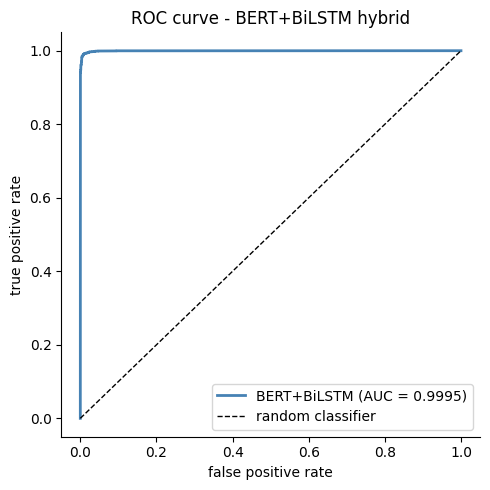

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase5_roc_curve.png


In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label='BERT+BiLSTM (AUC = {:.4f})'.format(auc_roc))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='random classifier')

ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curve - BERT+BiLSTM hybrid')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
p4 = charts_dir + '/phase5_roc_curve.png'
plt.savefig(p4, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p4)

## 9.  Summary

This shows the summary of everything produced in this phase.

In [12]:
print('Phase 5 complete')
print()
print('dashboard')
print('  Plotly Dash dashboard built and running')
print('  shows real vs fake counts, confidence scores')
print('  and recent predictions table')
print()
print('final evaluation results')
print('  accuracy  :', round(accuracy * 100, 2), '%')
print('  f1 score  :', round(f1, 4))
print('  precision :', round(precision, 4))
print('  recall    :', round(recall, 4))
print('  auc-roc   :', round(auc_roc, 4))
print('  latency   :', round(avg_latency_ms, 2), 'ms per article')
print()
print('charts saved for thesis Chapter 5')
print('  phase5_dashboard.png')
print('  phase5_benchmark_comparison.png')
print('  phase5_final_confusion_matrix.png')
print('  phase5_roc_curve.png')
print()
print('research question 4 answered:')
if accuracy * 100 >= 95:
    print('  target of 95% accuracy achieved -', round(accuracy * 100, 2), '%')
else:
    print('  accuracy is', round(accuracy * 100, 2), '% - discuss with supervisor')

Phase 5 complete

dashboard
  Plotly Dash dashboard built and running
  shows real vs fake counts, confidence scores
  and recent predictions table

final evaluation results
  accuracy  : 99.04 %
  f1 score  : 0.9904
  precision : 0.9904
  recall    : 0.9904
  auc-roc   : 0.9995
  latency   : 6.11 ms per article

charts saved for thesis Chapter 5
  phase5_dashboard.png
  phase5_benchmark_comparison.png
  phase5_final_confusion_matrix.png
  phase5_roc_curve.png

research question 4 answered:
  target of 95% accuracy achieved - 99.04 %


## 10. Recovery cell - run this if session disconnects

Remounts Drive and reloads the model and test results.
Run cells 1 and 2 first, then this, then continue
from whichever cell was not yet done.

In [6]:
# recovery cell for phase 5
# run after any session disconnect
# cells 1 and 2 must run first before this

import sqlite3, os
import pandas as pd

# check database
if os.path.exists(db_path):
    conn  = sqlite3.connect(db_path)
    count = conn.execute('SELECT COUNT(*) FROM predictions').fetchone()[0]
    conn.close()
    print('predictions in database:', count)
else:
    print('database not found - run Phase 4 first')

# check model
ckpt = model_dir + '/model3_bert_bilstm_hybrid.pt'
if os.path.exists(ckpt):
    print('hybrid model checkpoint found')
else:
    print('model not found - run Phase 3 first')

# check charts already saved
chart_files = [
    'phase5_dashboard.png',
    'phase5_benchmark_comparison.png',
    'phase5_final_confusion_matrix.png',
    'phase5_roc_curve.png',
]
print()
print('charts status:')
for f in chart_files:
    path   = charts_dir + '/' + f
    status = 'saved' if os.path.exists(path) else 'not yet - run that cell'
    print(' ', f, '-', status)

predictions in database: 100
hybrid model checkpoint found

charts status:
  phase5_dashboard.png - saved
  phase5_benchmark_comparison.png - saved
  phase5_final_confusion_matrix.png - saved
  phase5_roc_curve.png - saved


##  11.  Push to GitHub

Token entered via prompt - never saved in the notebook.

In [ ]:
import shutil, os, getpass

os.chdir('/content')

token = getpass.getpass('paste your github token and press enter: ')

username   = 'mikesayanka'
repo       = 'fake-news-detection-thesis'
folder     = 'phase5-dashboard-evaluation'
drive_base = '/content/drive/MyDrive/FakeNewsThesis'
clone_to   = '/content/push_temp'
message    = 'Phase 5: Plotly dashboard, full evaluation, benchmark comparison, ROC curve'

os.system('rm -rf ' + clone_to)
os.system('git config --global user.name "{}"'.format(username))
os.system('git config --global user.email "{}@users.noreply.github.com"'.format(username))

url = 'https://{}@github.com/{}/{}.git'.format(token, username, repo)
out = os.popen('git clone {} {} 2>&1'.format(url, clone_to)).read()
print(out)

if not os.path.exists(clone_to + '/.git'):
    print('clone failed - check token')
else:
    phase_dir  = clone_to + '/' + folder
    charts_out = phase_dir + '/charts'
    os.makedirs(charts_out, exist_ok=True)

    nb = drive_base + '/Phase5_Dashboard_Evaluation_GC3183502.ipynb'
    if os.path.exists(nb):
        shutil.copy(nb, phase_dir + '/Phase5_Dashboard_Evaluation_GC3183502.ipynb')
        print('notebook copied')
    else:
        print('save notebook to Drive first - File -> Save a copy in Drive')

    for chart in [
        'phase5_dashboard.png',
        'phase5_benchmark_comparison.png',
        'phase5_final_confusion_matrix.png',
        'phase5_roc_curve.png',
    ]:
        src = drive_base + '/charts/' + chart
        if os.path.exists(src):
            shutil.copy(src, charts_out + '/' + chart)
            print('copied:', chart)
        else:
            print('not found:', chart)

    os.chdir(clone_to)
    os.system('git add .')
    os.system('git commit -m "{}"'.format(message))
    out = os.popen('git push 2>&1').read()
    print(out)
    os.chdir('/content')
    os.system('rm -rf ' + clone_to)

    if 'main' in out or 'master' in out or 'up-to-date' in out:
        print('pushed to github')
        print('https://github.com/{}/{}'.format(username, repo))
    else:
        print('paste the output above here')